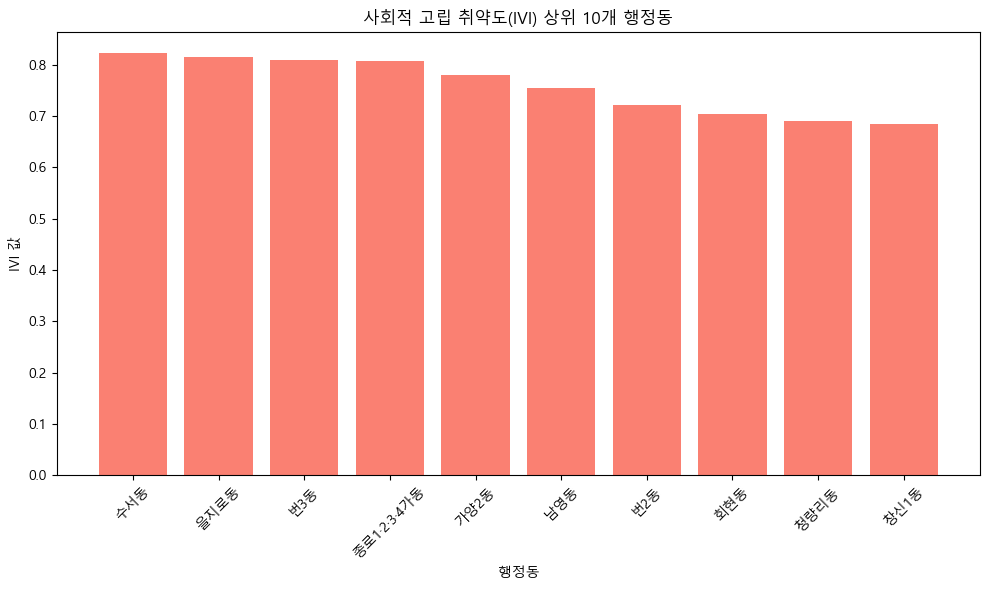

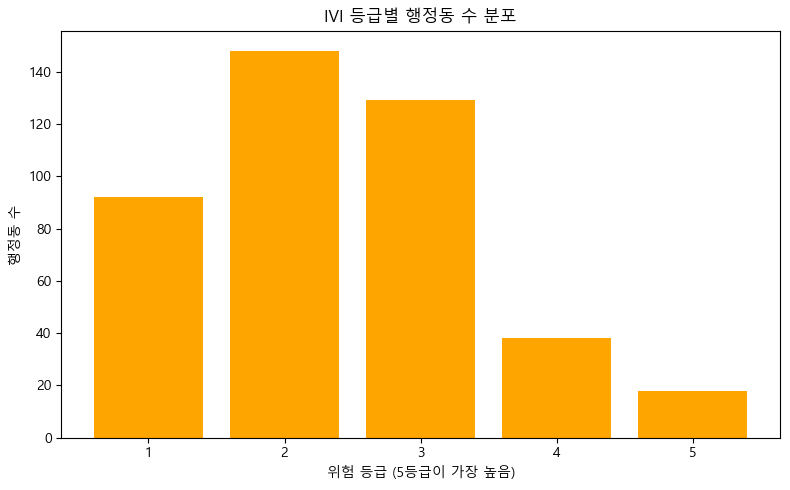

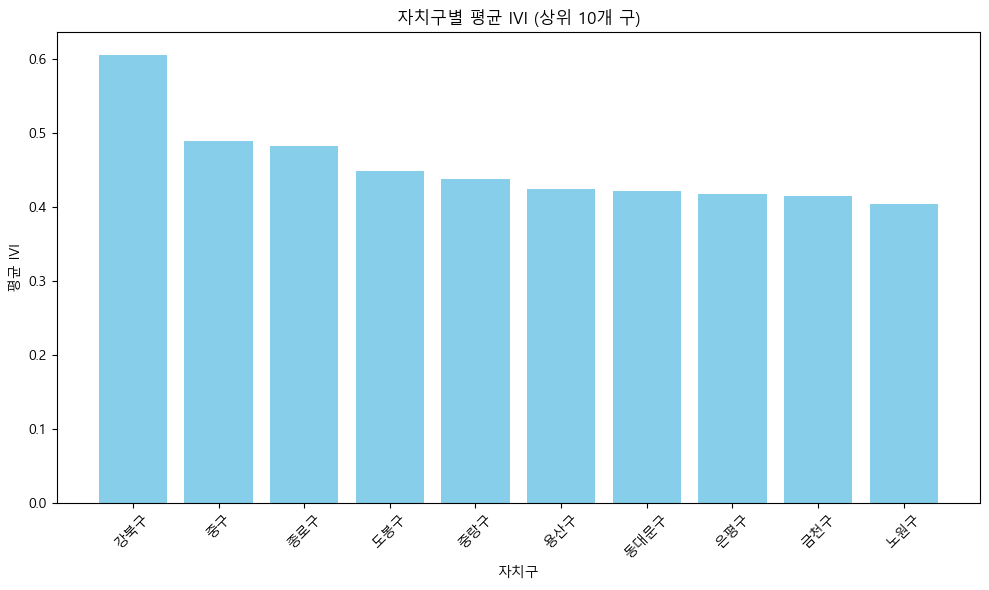

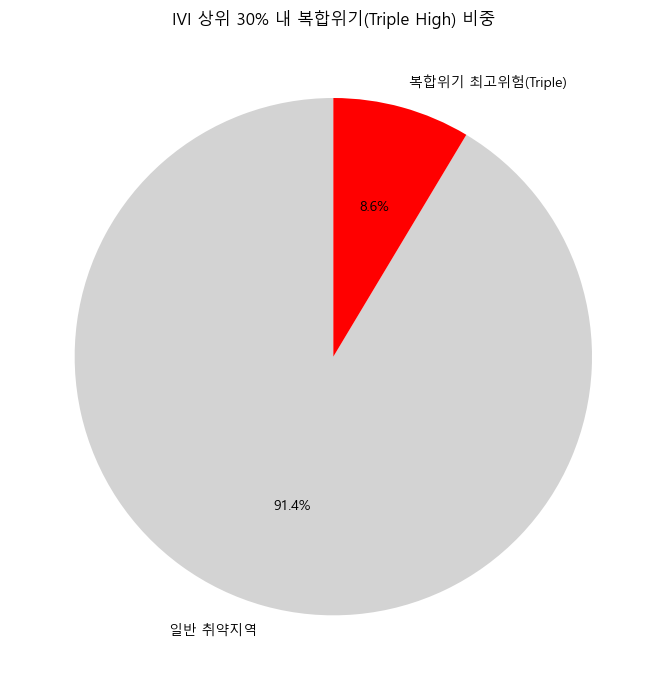

완료: 모든 그래프가 '../outputs/figures/' 폴더에 저장되었습니다.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# 0. 환경 설정 및 경로 설정
# -----------------------------
# 한글 폰트 (윈도우 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 기존 프로젝트 구조에 맞춘 저장 경로 설정
# 시각화 그래프이므로 outputs/figures 폴더를 사용합니다.
save_path = '../outputs/figures/' 

# 폴더가 혹시라도 없다면 생성 (안전장치)
os.makedirs(save_path, exist_ok=True)

# 데이터 불러오기
# 파일 위치에 따라 경로를 수정하세요. (예: '../data/output/final_crisis_index_by_dong_2021.csv')
try:
    df = pd.read_csv('../data/output/final_crisis_index_by_dong_2021.csv')
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

# IVI 등급 생성
def get_ivi_grade(val):
    if val >= 0.6: return 5
    elif val >= 0.5: return 4
    elif val >= 0.4: return 3
    elif val >= 0.3: return 2
    else: return 1

df['IVI_grade'] = df['IVI'].apply(get_ivi_grade)

# -----------------------------
# 1. IVI 상위 10개 행정동 bar chart
# -----------------------------
plt.figure(figsize=(10, 6))
top_10_ivi = df.sort_values('IVI', ascending=False).head(10)

plt.bar(top_10_ivi['행정동명'], top_10_ivi['IVI'], color='salmon')
plt.xticks(rotation=45)
plt.title('사회적 고립 취약도(IVI) 상위 10개 행정동')
plt.xlabel('행정동')
plt.ylabel('IVI 값')

plt.tight_layout()
# outputs/figures 폴더에 저장
plt.savefig(os.path.join(save_path, 'ivi_top10_bar.png'))
plt.show()

# -----------------------------
# 2. IVI 등급별 행정동 수 분포
# -----------------------------
plt.figure(figsize=(8, 5))
grade_counts = df['IVI_grade'].value_counts().sort_index()

plt.bar(grade_counts.index.astype(str), grade_counts.values, color='orange')
plt.title('IVI 등급별 행정동 수 분포')
plt.xlabel('위험 등급 (5등급이 가장 높음)')
plt.ylabel('행정동 수')

plt.tight_layout()
# outputs/figures 폴더에 저장
plt.savefig(os.path.join(save_path, 'ivi_grade_distribution.png'))
plt.show()

# -----------------------------
# 3. 자치구별 평균 IVI 비교 (상위 10개구)
# -----------------------------
plt.figure(figsize=(10, 6))
gu_avg_ivi = df.groupby('자치구명')['IVI'].mean().sort_values(ascending=False).head(10)

plt.bar(gu_avg_ivi.index, gu_avg_ivi.values, color='skyblue')
plt.xticks(rotation=45)
plt.title('자치구별 평균 IVI (상위 10개 구)')
plt.xlabel('자치구')
plt.ylabel('평균 IVI')

plt.tight_layout()
# outputs/figures 폴더에 저장
plt.savefig(os.path.join(save_path, 'gu_avg_ivi_chart.png'))
plt.show()

# -----------------------------
# 4. IVI 상위 30% 중 Triple High 지역 여부 (비중)
# -----------------------------
plt.figure(figsize=(7, 7))
ivi_top30 = df[df['IVI_top30_flag'] == 1]
triple_counts = ivi_top30['triple_high_flag'].value_counts()

plt.pie(triple_counts, labels=['일반 취약지역', '복합위기 최고위험(Triple)'], 
        autopct='%1.1f%%', startangle=90, colors=['lightgrey', 'red'])
plt.title('IVI 상위 30% 내 복합위기(Triple High) 비중')

plt.tight_layout()
# outputs/figures 폴더에 저장
plt.savefig(os.path.join(save_path, 'ivi_triple_pie_chart.png'))
plt.show()

print(f"완료: 모든 그래프가 '{save_path}' 폴더에 저장되었습니다.")

[IVI 결과 해석]
지도상에서 IVI(사회적 고립 취약도)는 서울의 동북권과 서북권 일부, 그리고 도심권을 중심으로 뚜렷한 고위험 공간 패턴을 보이고 있습니다.

고위험 등급(5등급) 집중 지역:

동북권: 강북구, 노원구, 중랑구 일대의 행정동에서 5등급(짙은 빨간색)이 밀집되어 나타납니다. 이는 해당 지역에 저층 주거지 및 노후 주거단지가 분포하며 고령 1인가구 비중이 높기 때문으로 풀이됩니다.

도심권 및 서북권: 종로구, 중구의 오래된 도심 지역과 은평구 일부 지역에서도 높은 취약도가 관찰됩니다. 특히 종로와 중구는 쪽방촌이나 노후 고시원 등 취약 주거 형태가 밀집된 곳을 중심으로 IVI 값이 매우 높게 형성되어 있습니다.

서남권: 강서구(가양동 일대), 관악구(대학동 일대) 등 공공임대주택 밀집 지역이나 1인 가구 밀집 지역에서 국지적인 고위험 패턴이 나타납니다.

공간적 차이:

고취약 지역: 주로 서울의 외곽(동북, 서남 끝단)과 구도심에 분포하며, 사회적 돌봄이 필요한 인구 밀도가 높습니다.

저취약 지역: 강남구, 서초구, 송파구 등 동남권 지역은 전반적으로 1~2등급(연한 노란색)의 낮은 취약도를 보입니다. 이는 상대적으로 양호한 주거 환경과 인구 구조를 반영한 결과로 보입니다.

[상위 행정동]
IVI 값이 가장 높은 상위 10개 행정동 현황입니다. (기준: final_crisis_index_by_dong_2021.csv)

| 자치구명 | 행정동명 | IVI | IVI_grade | CCI | CCI_rank | risk_type | Triple High |
|----------|----------|------|-----------|------|----------|------------|--------------|
| 강남구 | 수서동 | 0.822 | 5 | 0.668 | 5 | 사회고립 단일취약형 | 미포함 |
| 중구 | 을지로동 | 0.816 | 5 | 0.634 | 16 | 사회고립 단일취약형 | 미포함 |
| 강북구 | 번3동 | 0.810 | 5 | 0.676 | 4 | 사회고립+인프라취약형 | 미포함 |
| 종로구 | 종로1·2·3·4가동 | 0.808 | 5 | 0.517 | 219 | 사회고립 단일취약형 | 미포함 |
| 강서구 | 가양2동 | 0.780 | 5 | 0.707 | 2 | 복합위기 최고위험지역 | 포함 |
| 용산구 | 남영동 | 0.754 | 5 | 0.630 | 19 | 사회고립 단일취약형 | 미포함 |
| 강북구 | 번2동 | 0.723 | 5 | 0.696 | 3 | 복합위기 최고위험지역 | 포함 |
| 중구 | 회현동 | 0.704 | 5 | 0.529 | 183 | 사회고립 단일취약형 | 미포함 |
| 동대문구 | 청량리동 | 0.690 | 5 | 0.575 | 80 | 사회고립 단일취약형 | 미포함 |
| 종로구 | 창신1동 | 0.684 | 5 | 0.611 | 37 | 사회고립 단일취약형 | 미포함 |

[CCI와의 관계]
IVI가 높지만 CCI는 상대적으로 낮은 경우:

예: 종로1·2·3·4가동(IVI 4위 / CCI 219위), 회현동(IVI 8위 / CCI 183위)

이들 지역은 사회적 고립 취약성은 매우 높으나, 중심 상권에 위치하여 인프라 결핍(CDI)이 적고 지형상 수해 위험(RII)이 낮아 최종 CCI 순위는 중위권에 머물렀습니다.

IVI가 CCI 상승의 주요 원인인 경우:

예: 가양2동, 번2동, 번3동

이 지역들은 높은 IVI 값이 인프라 부족 또는 물리적 위험과 결합하면서 최종 복합위기지수(CCI)를 서울시 최상위권(Rank 2~4위)으로 끌어올리는 결정적인 요인이 되었습니다.

[정책적 시사점]
IVI가 높은 행정동은 단순한 경제적 지원을 넘어 '인적 연결망 회복'에 초점을 맞춘 정책이 우선되어야 합니다.

밀착형 안부 확인 체계: IVI 상위 지역(수서동, 을지로동, 번3동 등)을 대상으로 IT 기기를 활용한 스마트 플러그 모니터링, AI 안부 전화 서비스 등을 집중 배치하여 고독사를 예방해야 합니다.

지역 거점 돌봄 강화: 사회적 고립 취약도가 높은 행정동 내 유휴 공간을 활용하여 '우리동네 돌봄거점'을 조성하고, 고령 1인가구가 자연스럽게 교류할 수 있는 커뮤니티 프로그램을 활성화해야 합니다.

방문 복지 인력 집중 배치: IVI 5등급 지역에는 복지플래너 및 방문간호사를 우선 배치하여 건강 관리와 사회적 관계망 조사를 정기적으로 수행해야 합니다.

[추가 분석/시각화 제안]
자치구별 IVI 평균 비교: 특정 자치구 전체의 복지 수요를 파악하기 위해 자치구 단위의 평균 IVI 분석이 필요합니다.

IVI와 복지시설 공간 결합 지도: 취약도가 높은 곳에 실제 복지관이나 경로당이 충분히 배치되어 있는지 '복지 공급 적정성'을 시각화할 수 있습니다.

위험유형별(Risk Type) 산점도: IVI와 CDI(인프라) 간의 상관관계를 시각화하여, '사회적 고립'이 '인프라 부족'과 얼마나 동반되는지 분석할 수 있습니다.

[주의점]
상대적 지표의 한계: IVI는 인구 통계 자료를 바탕으로 산출된 상대적인 취약 가능성을 나타내며, 특정 가구의 실제 고립 상태를 확정하는 수치는 아닙니다.

복합적 해석 필요: IVI가 높다고 해서 반드시 물리적 재난(수해 등)에 취약하다는 뜻은 아닙니다. 반드시 CDI(인프라) 및 RII(수해) 지표와 결합하여 해당 지역의 구체적인 위기 성격을 규정해야 합니다.